<a href="https://colab.research.google.com/github/shahriar2711/google/blob/main/final_project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/final_project/train.csv", sep=";")
test_df  = pd.read_csv("/content/drive/MyDrive/final_project/test.csv", sep=";")


In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())


Train shape: (36532, 2)
Test shape: (8854, 2)
                                                text  label
0  republican committee pass bill would prohibit ...      0
1  trump treasury candidate bank accuse discrimin...      1
2  guess behind sicken ad show boy bully dad vote...      0
3  michigan treasurer call quick action detroit s...      1
4  clinton urge renew fight value washington reut...      1


In [ ]:
def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r'https?://\S+|www\.\S+', '', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean']  = test_df['text'].apply(clean_text)

train_df['label'] = train_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

train_df.head()


,text,label,text_clean
0,republican committee pass bill would prohibit ...,0,republican committee pass bill would prohibit ...
1,trump treasury candidate bank accuse discrimin...,1,trump treasury candidate bank accuse discrimin...
2,guess behind sicken ad show boy bully dad vote...,0,guess behind sicken ad show boy bully dad vote...
3,michigan treasurer call quick action detroit s...,1,michigan treasurer call quick action detroit s...
4,clinton urge renew fight value washington reut...,1,clinton urge renew fight value washington reut...


In [ ]:
MAX_VOCAB = 10000
MAX_LEN = 250

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['text_clean'])

X_train_seq = tokenizer.texts_to_sequences(train_df['text_clean'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['text_clean'])

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post')

y_train = train_df['label'].values
y_test  = test_df['label'].values

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (36532, 250)
X_test: (8854, 250)


In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {c: w for c, w in zip(classes, class_weights)}

class_weight_dict


{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}

In [ ]:
embedding_dim = 64

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_VOCAB, embedding_dim, input_length=MAX_LEN),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=32,
    shuffle=True,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/8
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.6149 - loss: 0.6088 - val_accuracy: 0.7482 - val_loss: 0.5883
Epoch 2/8
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 76s 71ms/step - accuracy: 0.7615 - loss: 0.4364 - val_accuracy: 0.5824 - val_loss: 0.5121
Epoch 3/8
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 75s 73ms/step - accuracy: 0.7561 - loss: 0.4432 - val_accuracy: 0.9037 - val_loss: 0.3175
Epoch 4/8
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 71s 69ms/step - accuracy: 0.8671 - loss: 0.3353 - val_accuracy: 0.8446 - val_loss: 0.3840
Epoch 5/8
1028/1028 ━━━━━━━━━━━━━━━━━━━━ 89s 76ms/step - accuracy: 0.7499 - loss: 0.4582 - val_accuracy: 0.7843 - val_loss: 0.3874


In [ ]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step
Accuracy:  0.8700
Precision: 0.8123
Recall:    0.9499
F1 Score:  0.8757


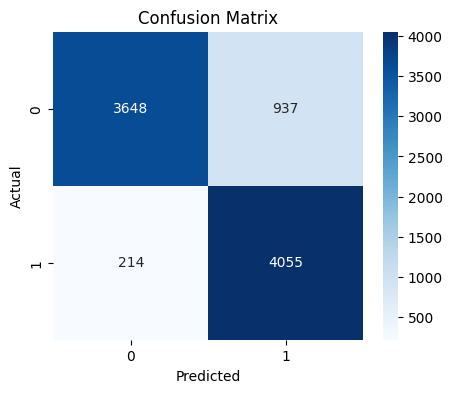

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


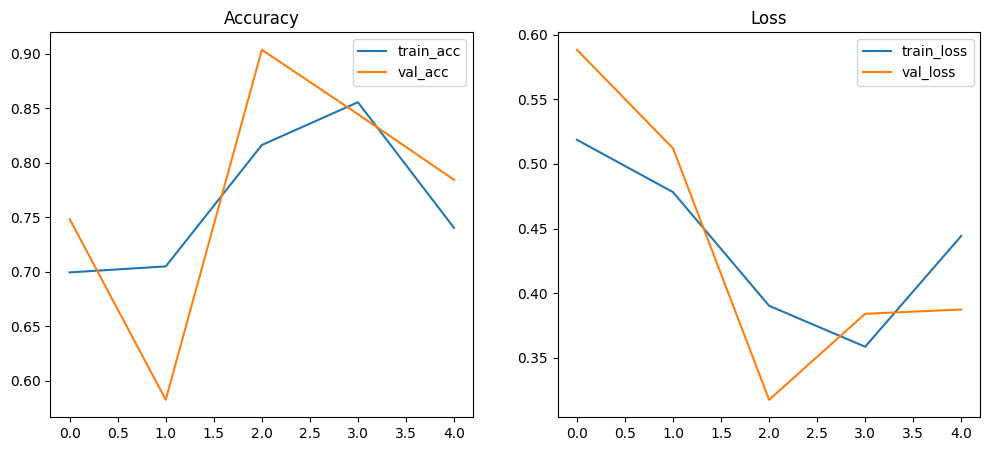

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")

plt.show()


In [ ]:
model.save("simple_rnn_fakenews.h5")

import json
with open("tokenizer.json","w",encoding="utf-8") as f:
    f.write(tokenizer.to_json())

print("Saved model and tokenizer.")


Saved model and tokenizer.


In [ ]:
import re
import tensorflow as tf

def normalize(data):
    normalized = []
    for i in data:
        i = i.lower()
        i = re.sub('https?://\S+|www\.\S+', '', i)
        i = re.sub('\\W', ' ', i)
        i = re.sub('\n', '', i)
        i = re.sub(' +', ' ', i)
        i = re.sub('^ ', '', i)
        i = re.sub(' $', '', i)
        normalized.append(i)
    return normalized

def predict_news(text):
    norm = normalize([text])
    seq = tokenizer.texts_to_sequences(norm)
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=256, padding='post')
    pred = model.predict(padded)[0][0]

    print("\nPrediction Score:", pred)

    if pred >= 0.5:
        print("✔ REAL NEWS")
    else:
        print("✘ FAKE NEWS")



<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipython-input-2015431462.py:8: SyntaxWarning: invalid escape sequence '\S'
  i = re.sub('https?://\S+|www\.\S+', '', i)


In [ ]:
predict_news("A new study shows drinking water prevents memory loss.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step

Prediction Score: 0.11180571
✘ FAKE NEWS


In [ ]:
predict_news("trump treasury candidate bank accuse discrimination.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Prediction Score: 0.68507344
✔ REAL NEWS
